# Преобразовать существующий код для распознавания последовательности рукописных символов в текст.
# Написать генератор произвольной последовательности рукописных символов.

# ГЕНЕРАЦИЯ НАБОРА ДАННЫХ
# Сгенерировать набор текстовых строк из допустимых символов.
# Каждому набору поставить в соответствие массив изображений соответствующих символов.
# Добавить пробелы для разделения слов, символы пробелов не использовать во время классификации.

# КЛАССИФИКАЦИЯ (k ближайших соседей) (пример AIM practice 2)
# Часть символов оставить для обучения классификатора . Остальные классифицировать
# по аналогии с примером mnist с прошлого занятия. Т.е. преобразовывать изображение в вектор.
# Выбрать оптимальный классификатор в зависимости от k - количества соседей.
# Метрика для измерения точности классификации и выбора оптимального классификатора относительно параметра k - accuracy.

# РАСПОЗНАВАНИЕ
# Заменить inf_net на последовательное применение следующих шагов:
# 1. Генерация изображения с последовательностью символов
# 2. Выделение объектов оставляете как есть.
# 3. Применить k-nn для решения задачи классификации. 
# 4. Вывести результат

Symbols:  ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*']
Sequence is generating: 0(t084x509


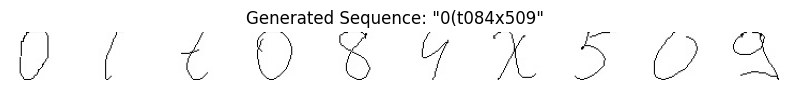

Sequence processing: "0(t084x509"


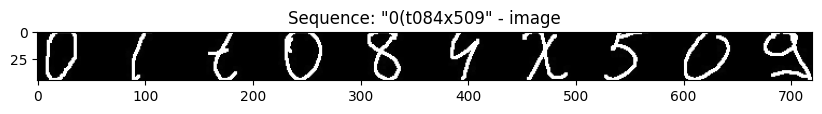

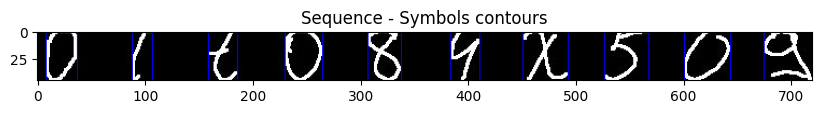

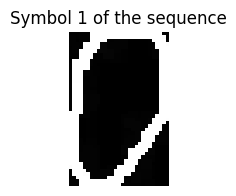

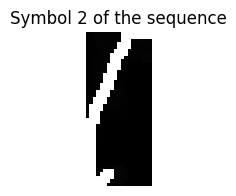

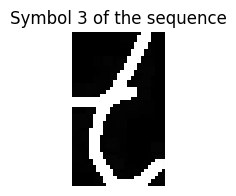

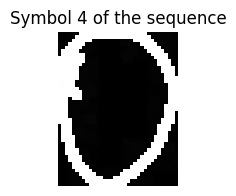

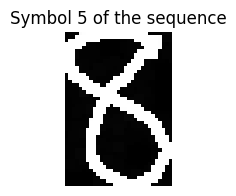

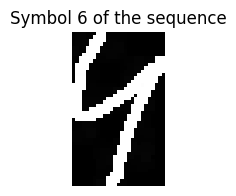

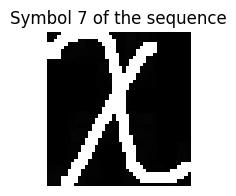

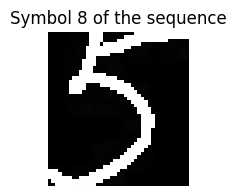

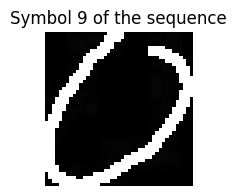

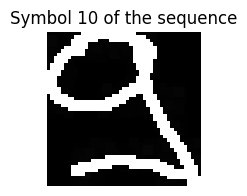

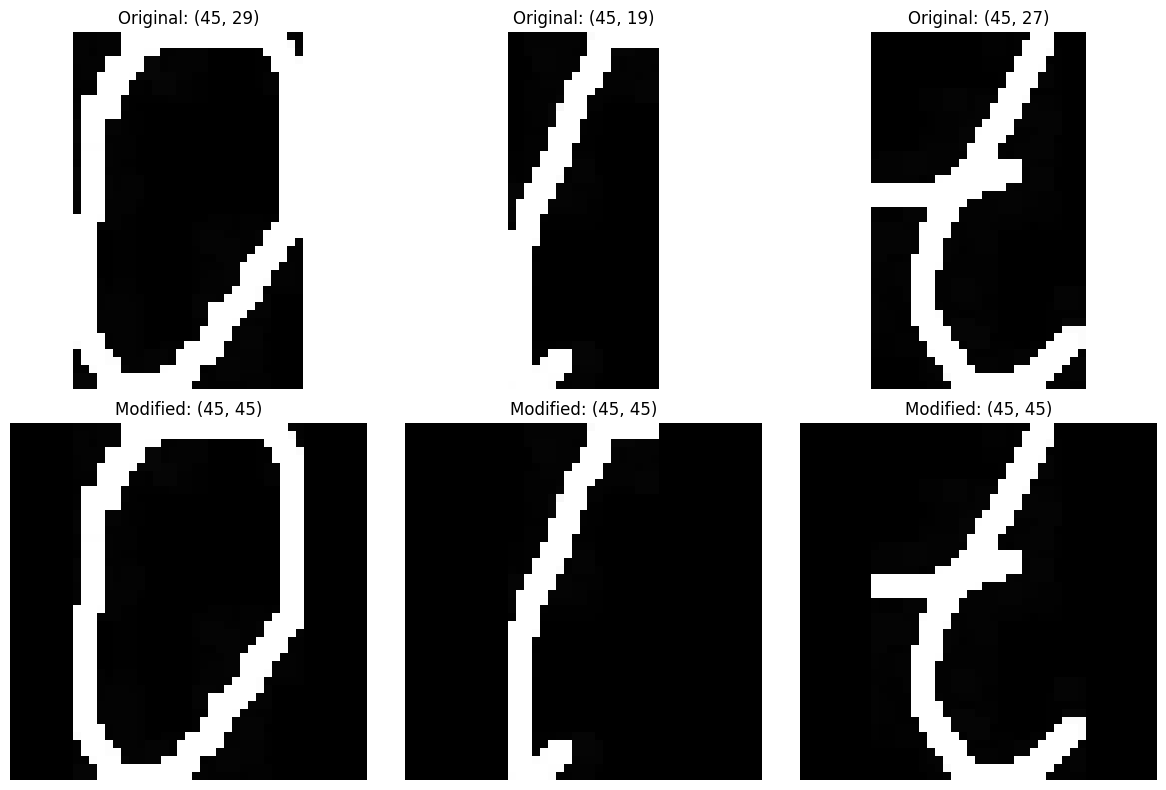

Selection for training: 180225 images
KNN model with n=1 is trained.
KNN model with n=3 is trained.
KNN model with n=5 is trained.
KNN model with n=7 is trained.

 Sequence:
Original: '0(t084x509'

Model: knn1


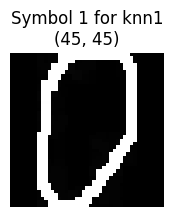

    Predicted as: '0'


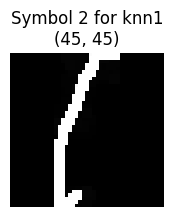

    Predicted as: '('


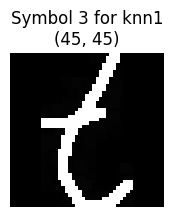

    Predicted as: 't'


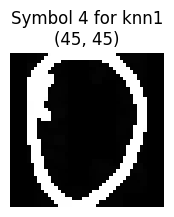

    Predicted as: '0'


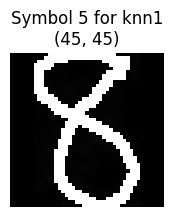

    Predicted as: '8'


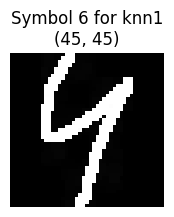

    Predicted as: '4'


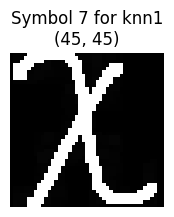

    Predicted as: 'X'


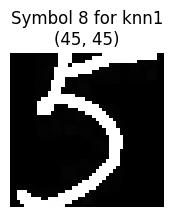

    Predicted as: '5'


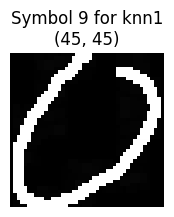

    Predicted as: '0'


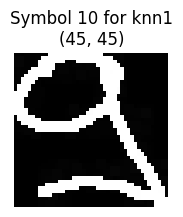

    Predicted as: '2'
Predicted: '0(t084X502'
   Error at position 7: expected 'x', actual 'X'
   Error at position 10: expected '9', actual '2'
Accuracy for knn1: 0.80 (8/10 symbols)

Model: knn3


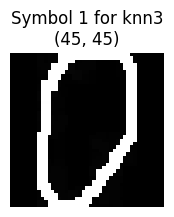

    Predicted as: '0'


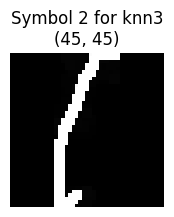

    Predicted as: '('


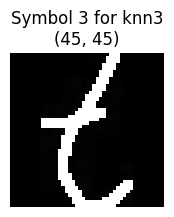

    Predicted as: 't'


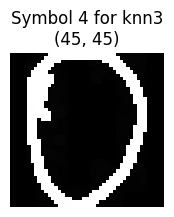

    Predicted as: '0'


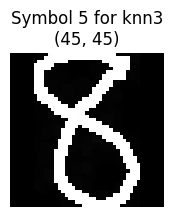

    Predicted as: '8'


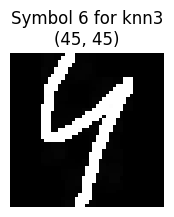

    Predicted as: '4'


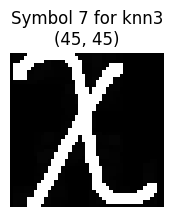

    Predicted as: 'X'


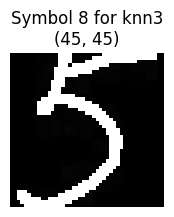

    Predicted as: '5'


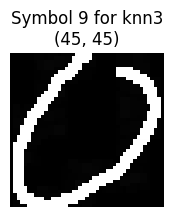

    Predicted as: '0'


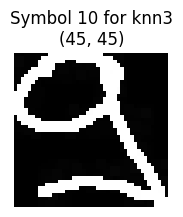

    Predicted as: '3'
Predicted: '0(t084X503'
   Error at position 7: expected 'x', actual 'X'
   Error at position 10: expected '9', actual '3'
Accuracy for knn3: 0.80 (8/10 symbols)

Model: knn5


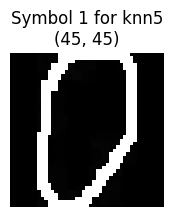

    Predicted as: '0'


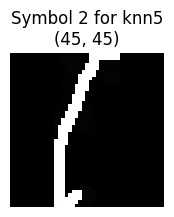

    Predicted as: '('


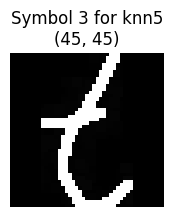

    Predicted as: 't'


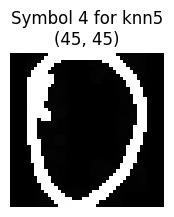

    Predicted as: '0'


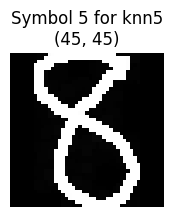

    Predicted as: '8'


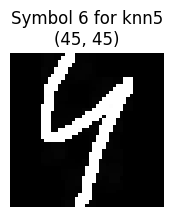

    Predicted as: '4'


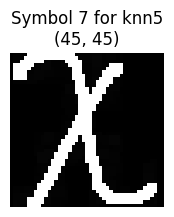

    Predicted as: 'X'


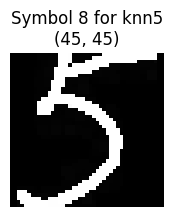

    Predicted as: '5'


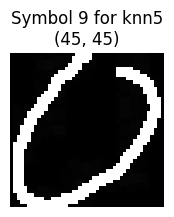

    Predicted as: '0'


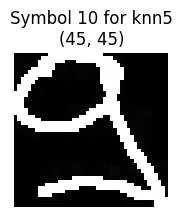

    Predicted as: '3'
Predicted: '0(t084X503'
   Error at position 7: expected 'x', actual 'X'
   Error at position 10: expected '9', actual '3'
Accuracy for knn5: 0.80 (8/10 symbols)

Model: knn7


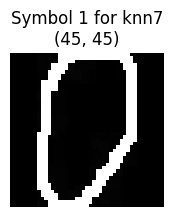

    Predicted as: '0'


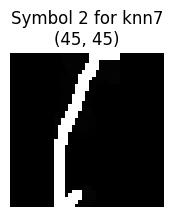

    Predicted as: '('


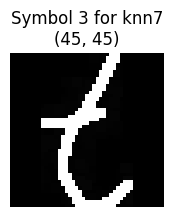

    Predicted as: '('


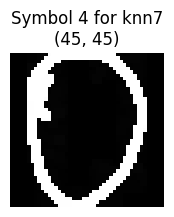

    Predicted as: '0'


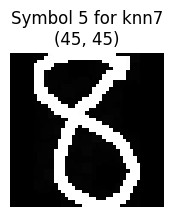

    Predicted as: '8'


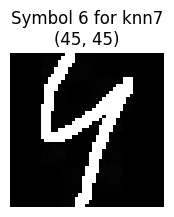

    Predicted as: '4'


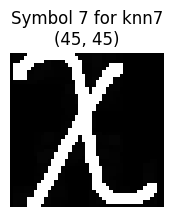

    Predicted as: 'X'


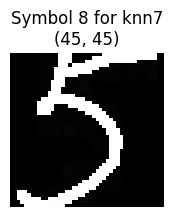

    Predicted as: '5'


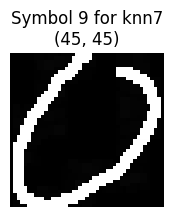

    Predicted as: '0'


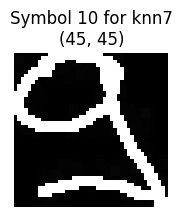

    Predicted as: '3'
Predicted: '0((084X503'
   Error at position 3: expected 't', actual '('
   Error at position 7: expected 'x', actual 'X'
   Error at position 10: expected '9', actual '3'
Accuracy for knn7: 0.70 (7/10 symbols)

All models:
knn1  | Accuracy:  80.00% | 8/10 | Prediction: '0(t084X502'
knn3  | Accuracy:  80.00% | 8/10 | Prediction: '0(t084X503'
knn5  | Accuracy:  80.00% | 8/10 | Prediction: '0(t084X503'
knn7  | Accuracy:  70.00% | 7/10 | Prediction: '0((084X503'


In [4]:
import os.path
import random

import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


class SymbolsSequenceGenerator:
    def __init__(self, dataset_path):
        self.symbols = list(('(', ')', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 't', 'x', 'y', ',', '+', '-', '*'))
        self.dataset_path = dataset_path

        print('Symbols: ', self.symbols)

    def get_symbol_image(self, symbol):
        folder_name = symbol
        if symbol == 'x':
            folder_name = 'X'

        symbol_path = os.path.join(self.dataset_path, folder_name)

        imgs = [i for i in os.listdir(symbol_path)]
        imgs.sort()

        start_ind = int(len(imgs) * 0.8)
        imgs_validation = imgs[start_ind:]

        random_img = random.choice(imgs_validation)
        img_path = os.path.join(symbol_path, random_img)
        img_data = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        return img_data

    def generate_sequence(self, seq_length):
        seq = ''.join(random.choices(self.symbols, k=seq_length))
        imgs = []

        print(f"Sequence is generating: {seq}")

        for char in seq:
            img = self.get_symbol_image(char)
            if img is not None:
                imgs.append(img)

        return seq, imgs


generator = SymbolsSequenceGenerator("data")


def create_seq_image(imgs, space=20):
    max_height = max(img.shape[0] for img in imgs)
    width = sum(img.shape[1] for img in imgs) + space * (len(imgs) - 1)

    seq_img = np.ones((max_height, width), dtype=np.uint8) * 255

    x_offset = 0
    for img in imgs:
        h, w = img.shape
        y_offset = (max_height - h)
        seq_img[y_offset:y_offset + h, x_offset:x_offset + w] = img
        x_offset += w + space

    return seq_img


seq, imgs = generator.generate_sequence(10)
seq_img = create_seq_image(imgs, 30)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(seq_img, cmap='gray')
ax.set_title(f'Generated Sequence: "{seq}"')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Sequence processing: "{seq}"')

all_data = []

kernel = np.ones((3, 3), np.uint8)

img_gray = seq_img
img_gray = cv2.erode(img_gray, kernel, iterations=1)
img_gray = cv2.bitwise_not(img_gray)

base_size = img_gray.shape[0], img_gray.shape[1]
base = np.zeros(base_size, dtype=np.uint8)
base[0: img_gray.shape[0], 0: img_gray.shape[1]] = img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)

img_rgb = base

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Sequence: "{seq}" - image')
plt.show()

ret, thresh = cv2.threshold(img_rgb, 127, 255, 0)
thresh = np.uint8(thresh)

contours, h = cv2.findContours(thresh[:, :, 0], cv2.RETR_EXTERNAL, 2)
crops = []
contours_sorted = sorted(contours, key=lambda cnt: cv2.boundingRect(cnt)[0])

for i in range(len(contours_sorted)):
    cnt = contours_sorted[i]
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    while w > 45:
        w -= 1

    if w * h > 50:
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 0, 255), 1)
        crops.append([x, y, w, h])

plt.figure(figsize=(10, 3))
plt.imshow(img_rgb)
plt.title(f'Sequence - Symbols contours')
plt.show()

seq_symbols = []
for i in range(len(crops)):
    x, y, w, h = crops[i]

    img_crop = img_gray[y:y + h, x:x + w]
    base = img_crop.copy()

    plt.figure(figsize=(3, 2))
    plt.imshow(base, cmap="gray")
    plt.title(f'Symbol {i + 1} of the sequence')
    plt.axis('off')
    seq_symbols.append((x, base))
    plt.show()

all_data.append({
    'sequence_text': seq,
    'symbols': seq_symbols
})


def center_and_square_image(img, target_size=45):
    h, w = img.shape

    squared = np.zeros((target_size, target_size), dtype=np.uint8)

    x_offset = (target_size - w) // 2
    y_offset = (target_size - h) // 2

    squared[y_offset: y_offset + h, x_offset: x_offset + w] = img

    return squared


all_data_45 = []
seq_data = all_data[0]
sequence_text = seq_data['sequence_text']
symbols_data = seq_data['symbols']

sorted_symbols = sorted(symbols_data, key=lambda item: item[0])
resized_symbols = []

for x, symbol_img in sorted_symbols:
    original_size = symbol_img.shape
    resized_img = center_and_square_image(symbol_img)
    resized_symbols.append((x, resized_img))

all_data_45.append({
    'sequence_text': sequence_text,
    'symbols': resized_symbols
})

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(min(3, len(all_data_45[0]['symbols']))):
    orig_img = all_data[0]['symbols'][i][1]
    resized_img = all_data_45[0]['symbols'][i][1]

    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(f'Original: {orig_img.shape}')
    axes[0, i].axis('off')

    axes[1, i].imshow(resized_img, cmap='gray')
    axes[1, i].set_title(f'Modified: {resized_img.shape}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


def load_training_data(data_path, symbols_list, training_ratio=0.8):
    training_features = []
    training_labels = []

    for s in symbols_list:
        symbol_path = os.path.join(data_path, s)
        img_list = [f for f in os.listdir(symbol_path) if os.path.isfile(os.path.join(symbol_path, f))]
        img_list.sort()

        split_point = int(len(img_list) * training_ratio)
        training_images = img_list[:split_point]

        for img_file in training_images:
            img_path = os.path.join(symbol_path, img_file)
            img_data = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_data is not None:
                training_features.append(img_data.flatten())
                if s == 'x':
                    s = 'X'

                training_labels.append(s)

    return np.array(training_features), np.array(training_labels)


symbols_set = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '-', 'times', 't', 'X', 'y', 'w', 'h', '(', ')',
               ',']
x_train, y_train = load_training_data('data', symbols_set)

print(f"Selection for training: {len(x_train)} images")

neighbor_variants = [1, 3, 5, 7]
knn_models = {}

for n in neighbor_variants:
    classifier = KNeighborsClassifier(n_neighbors=n)
    classifier.fit(x_train, y_train)
    knn_models[n] = classifier

    print(f"KNN model with n={n} is trained.")


def predict_symbol(model, img):
    img = cv2.bitwise_not(img)
    img_flat = img.flatten()
    prediction = model.predict([img_flat])
    return prediction[0]


seq_data = all_data_45[0]
original_text = seq_data['sequence_text']
symbols_data = seq_data['symbols']

print(f"\n Sequence:")
print(f"Original: '{original_text}'")

models = {f"knn{n}": knn_models[n] for n in neighbor_variants}

results = {}

for model_name, model in models.items():
    print(f"\n{'=' * 50}")
    print(f"Model: {model_name}")
    print(f"{'=' * 50}")

    predicted_symbols = []

    for j, (x, symbol_img) in enumerate(symbols_data):
        plt.figure(figsize=(3, 2))
        plt.imshow(symbol_img, cmap='gray')
        plt.title(f'Symbol {j + 1} for {model_name}\n{symbol_img.shape}')
        plt.axis('off')
        plt.show()

        predicted_char = predict_symbol(model, symbol_img)
        predicted_symbols.append(predicted_char)
        print(f"    Predicted as: '{predicted_char}'")

    predicted_text = ''.join(predicted_symbols)
    print(f"Predicted: '{predicted_text}'")

    correct_chars = sum(1 for orig, pred in zip(original_text, predicted_text) if orig == pred)
    total_chars = len(original_text)
    accuracy = correct_chars / total_chars

    if original_text != predicted_text:
        for idx, (orig_char, pred_char) in enumerate(zip(original_text, predicted_text)):
            if orig_char != pred_char:
                print(f"   Error at position {idx + 1}: expected '{orig_char}', actual '{pred_char}'")

    print(f"Accuracy for {model_name}: {accuracy:.2f} ({correct_chars}/{total_chars} symbols)")

    results[model_name] = {
        'predicted_text': predicted_text,
        'accuracy': accuracy,
        'correct_chars': correct_chars,
        'total_chars': total_chars
    }

print(f"\n{'=' * 60}")
print("All models:")
print(f"{'=' * 60}")

sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

for model_name, result in sorted_results:
    accuracy_percent = result['accuracy'] * 100
    print(
        f"{model_name:5} | Accuracy: {accuracy_percent:6.2f}% | {result['correct_chars']}/{result['total_chars']} | "
        f"Prediction: '{result['predicted_text']}'")
